In [18]:
import numpy as np
class SimpleLinearRegression:
    def __init__(self):
        self.coefficient_ = None
        self.intercept_ = None
        self.r2score_ = None
    def fit(self, X, y):
        n = len(X)
        X_b = np.c_[np.ones((n, 1)), X]

        self.coefficients_ = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
        self.intercept_ = self.coefficients_[0]

        y_pred = X_b.dot(self.coefficients_)

        self.r2score_ = 1 - (np.sum(y - y_pred) ** 2) / np.sum(y - np.mean(y))
        self.y_pred_ = y_pred
    def predict(self, X):
        X_b = np.c_[np.ones(len(X), 1), X]
        return  X_b.dot(self.coefficients_)

In [19]:
X_simple = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)
y_simple = np.array([2, 4, 5, 4, 5, 7, 8, 9, 10, 12])

slr = SimpleLinearRegression()
slr.fit(X_simple, y_simple)

print(f'Simple LR Coefficients: {slr.coefficients_}')
print(f'R2 Score: {slr.r2score_}')

Simple LR Coefficients: [1.06666667 1.00606061]
R2 Score: 0.9999999999999432


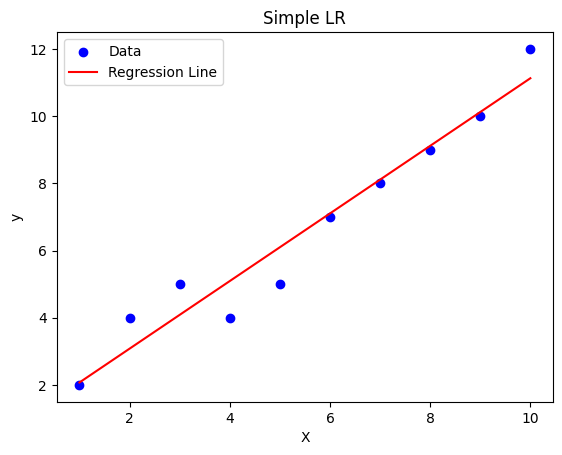

In [21]:
import matplotlib.pyplot as plt

plt.scatter(X_simple, y_simple, color = 'blue', label = 'Data')
plt.plot(X_simple, slr.y_pred_, color = 'red', label = 'Regression Line')
plt.title('Simple LR')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

In [27]:
class MultipleLinearRegression:
    def __init__(self):
        self.coefficients_ = None
        self.intercept_ = None
        self.r2score_ = None

    def fit(self, X, y):
        n = X.shape[0]
        X_b = np.c_[np.ones((n, 1)), X]
        self.coefficients_ = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

        self.intercept_ = self.coefficients_[0]

        y_pred = X_b.dot(self.coefficients_)

        self.r2score_ = 1 - (np.sum(y - y_pred) ** 2) / np.sum(y - np.mean(y))

        self.y_pred_ = y_pred
    def predict(self, X):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return X_b.dot(self.coefficients_)

In [23]:
np.random.seed(42)

X1 = np.random.randint(1, 11, 15)
X2 = np.random.randint(1, 11, 15)

X_multi = np.column_stack((X1, X2))

y_multi = 1 + 2*X1 + 3*X2 + np.random.randn(15)*2

In [28]:
y_multi

array([28.91123455, 15.22184518, 38.69801285, 29.75139604, 19.79872262,
       35.4166125 ,  8.79658678, 48.70455637, 34.97300555, 35.88457814,
       13.64508982, 44.5583127 , 26.41772719, 24.08065975, 22.3436279 ])

In [29]:
X_multi

array([[ 7,  5],
       [ 4,  2],
       [ 8,  8],
       [ 5,  6],
       [ 7,  2],
       [10,  5],
       [ 3,  1],
       [ 7, 10],
       [ 8,  6],
       [ 5,  9],
       [ 4,  1],
       [ 8, 10],
       [ 8,  3],
       [ 3,  7],
       [ 6,  4]])

In [30]:
mlr = MultipleLinearRegression()
mlr.fit(X_multi, y_multi)

print(f'Multi LR Coefficients: {mlr.coefficients_}')
print(f'R2 Score: {mlr.r2score_}')


Multi LR Coefficients: [-0.025293    2.14085712  2.89217279]
R2 Score: 1.0000000000020788


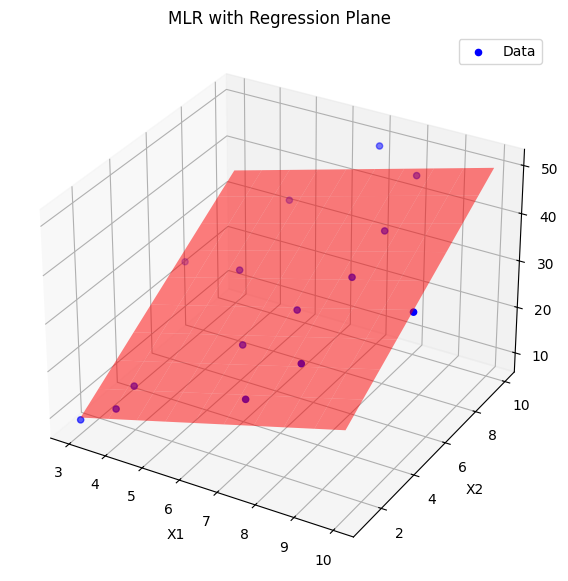

In [34]:
fig = plt.figure(figsize = (10, 7))
ax = fig.add_subplot(111, projection = '3d')

ax.scatter(X_multi[:, 0], X_multi[:, 1], y_multi, color = 'blue', label = 'Data')

x1_surf, x2_surf = np.meshgrid(
    np.linspace(X_multi[:, 0].min(), X_multi[:, 0].max(), 10),
    np.linspace(X_multi[:, 1].min(), X_multi[:, 1].max(), 10)
)

pred_surf = mlr.predict(np.c_[x1_surf.ravel(), x2_surf.ravel()]).reshape(x1_surf.shape)

ax.plot_surface(x1_surf, x2_surf, pred_surf, color = 'red', alpha = 0.5,
                rstride = 1, cstride = 1)
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('y')
ax.set_title('MLR with Regression Plane')
ax.legend()
plt.show()